Keras를 사용한 분류 모델

In [1]:
import os
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import keras

from keras.models import Sequential
from keras.layers import Dense
from keras.layers import Input
from keras.utils import to_categorical

import matplotlib.pyplot as plt

# import the data
from keras.datasets import mnist

In [2]:
# read the data
(X_train, y_train), (X_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [3]:
X_train.shape

(60000, 28, 28)

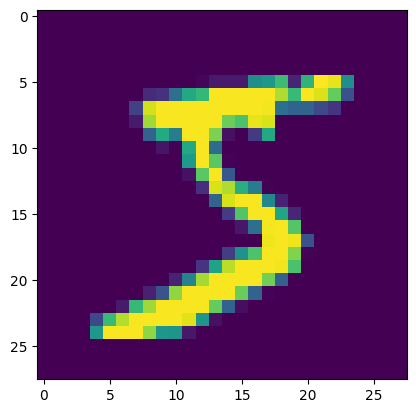

In [4]:
plt.imshow(X_train[0])

In [5]:
# flatten images into one-dimensional vector

num_pixels = X_train.shape[1] * X_train.shape[2] # find size of one-dimensional vector

X_train = X_train.reshape(X_train.shape[0], num_pixels).astype('float32') # flatten training images
X_test = X_test.reshape(X_test.shape[0], num_pixels).astype('float32') # flatten test images

In [6]:
# normalize inputs from 0-255 to 0-1
X_train = X_train / 255
X_test = X_test / 255

In [7]:
# one hot encode outputs
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

num_classes = y_test.shape[1]
print(num_classes)

10


In [8]:
# define classification model
def classification_model():
    # create model
    
    model = Sequential()
    model.add(Input(shape=(num_pixels,)))
    model.add(Dense(num_pixels, activation='relu'))
    model.add(Dense(100, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))
    
    
    # compile model
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [9]:
# build the model
model = classification_model()

# fit the model
model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, verbose=2)

# evaluate the model
scores = model.evaluate(X_test, y_test, verbose=0)

Epoch 1/10
1875/1875 - 10s - 5ms/step - accuracy: 0.9428 - loss: 0.1874 - val_accuracy: 0.9626 - val_loss: 0.1263
Epoch 2/10
1875/1875 - 7s - 4ms/step - accuracy: 0.9761 - loss: 0.0777 - val_accuracy: 0.9728 - val_loss: 0.0886
Epoch 3/10
1875/1875 - 7s - 4ms/step - accuracy: 0.9826 - loss: 0.0544 - val_accuracy: 0.9793 - val_loss: 0.0714
Epoch 4/10
1875/1875 - 7s - 4ms/step - accuracy: 0.9872 - loss: 0.0399 - val_accuracy: 0.9781 - val_loss: 0.0693
Epoch 5/10
1875/1875 - 7s - 4ms/step - accuracy: 0.9895 - loss: 0.0324 - val_accuracy: 0.9755 - val_loss: 0.0877
Epoch 6/10
1875/1875 - 8s - 4ms/step - accuracy: 0.9923 - loss: 0.0241 - val_accuracy: 0.9784 - val_loss: 0.0867
Epoch 7/10
1875/1875 - 7s - 4ms/step - accuracy: 0.9926 - loss: 0.0229 - val_accuracy: 0.9777 - val_loss: 0.0967
Epoch 8/10
1875/1875 - 7s - 4ms/step - accuracy: 0.9944 - loss: 0.0175 - val_accuracy: 0.9804 - val_loss: 0.0807
Epoch 9/10
1875/1875 - 8s - 4ms/step - accuracy: 0.9941 - loss: 0.0188 - val_accuracy: 0.9812 -

In [10]:
print('Accuracy: {}% \n Error: {}'.format(scores[1], 1 - scores[1]))

Accuracy: 0.979200005531311% 
 Error: 0.020799994468688965


In [11]:
model.save('classification_model.keras')

In [12]:
pretrained_model = keras.saving.load_model('classification_model.keras')

In [13]:
def classification_model_6layers():
    # create model
    
    model = Sequential()
    model.add(Input(shape=(num_pixels,)))
    model.add(Dense(num_pixels, activation='relu'))
    model.add(Dense(100, activation='relu'))
    model.add(Dense(100, activation='relu'))
    model.add(Dense(100, activation='relu'))
    model.add(Dense(100, activation='relu'))
    model.add(Dense(num_classes, activation='softmax'))
    
    
    # compile model
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

# build the model
model_6layers = classification_model_6layers()

# fit the model
model_6layers.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, verbose=2)

# evaluate the model
scores_6layers = model_6layers.evaluate(X_test, y_test, verbose=0)

print('Accuracy_3_layers: {}% \n Accuracy_6_layers: {}'.format(scores[1], scores_6layers[1]))

Epoch 1/10
1875/1875 - 8s - 4ms/step - accuracy: 0.9316 - loss: 0.2214 - val_accuracy: 0.9592 - val_loss: 0.1336
Epoch 2/10
1875/1875 - 7s - 4ms/step - accuracy: 0.9702 - loss: 0.0998 - val_accuracy: 0.9709 - val_loss: 0.0969
Epoch 3/10
1875/1875 - 7s - 3ms/step - accuracy: 0.9780 - loss: 0.0739 - val_accuracy: 0.9761 - val_loss: 0.0875
Epoch 4/10
1875/1875 - 7s - 3ms/step - accuracy: 0.9833 - loss: 0.0561 - val_accuracy: 0.9775 - val_loss: 0.0818
Epoch 5/10
1875/1875 - 6s - 3ms/step - accuracy: 0.9861 - loss: 0.0473 - val_accuracy: 0.9798 - val_loss: 0.0856
Epoch 6/10
1875/1875 - 7s - 4ms/step - accuracy: 0.9888 - loss: 0.0395 - val_accuracy: 0.9796 - val_loss: 0.0822
Epoch 7/10
1875/1875 - 6s - 3ms/step - accuracy: 0.9900 - loss: 0.0332 - val_accuracy: 0.9813 - val_loss: 0.0786
Epoch 8/10
1875/1875 - 6s - 3ms/step - accuracy: 0.9918 - loss: 0.0297 - val_accuracy: 0.9784 - val_loss: 0.0993
Epoch 9/10
1875/1875 - 6s - 3ms/step - accuracy: 0.9911 - loss: 0.0307 - val_accuracy: 0.9824 - 

In [14]:
#load the saved model
pretrained_model = keras.saving.load_model('classification_model.keras')

print("Pre-trained model loaded successufully")

# Further train the loaded model
pretrained_model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=10, verbose=2)

# evaluate the model
scores_20_epochs = pretrained_model.evaluate(X_test, y_test, verbose=0)
print('Accuracy_10_epochs: {}% \n Accuracy_20_epochs: {}'.format(scores[1], scores_20_epochs[1]))

Pre-trained model loaded successufully
Epoch 1/10
1875/1875 - 7s - 4ms/step - accuracy: 0.9949 - loss: 0.0159 - val_accuracy: 0.9802 - val_loss: 0.0913
Epoch 2/10
1875/1875 - 6s - 3ms/step - accuracy: 0.9963 - loss: 0.0125 - val_accuracy: 0.9830 - val_loss: 0.0869
Epoch 3/10
1875/1875 - 6s - 3ms/step - accuracy: 0.9964 - loss: 0.0111 - val_accuracy: 0.9811 - val_loss: 0.1055
Epoch 4/10
1875/1875 - 6s - 3ms/step - accuracy: 0.9960 - loss: 0.0137 - val_accuracy: 0.9814 - val_loss: 0.0928
Epoch 5/10
1875/1875 - 6s - 3ms/step - accuracy: 0.9974 - loss: 0.0093 - val_accuracy: 0.9850 - val_loss: 0.0936
Epoch 6/10
1875/1875 - 6s - 3ms/step - accuracy: 0.9961 - loss: 0.0141 - val_accuracy: 0.9810 - val_loss: 0.1145
Epoch 7/10
1875/1875 - 6s - 3ms/step - accuracy: 0.9974 - loss: 0.0088 - val_accuracy: 0.9814 - val_loss: 0.1153
Epoch 8/10
1875/1875 - 6s - 3ms/step - accuracy: 0.9973 - loss: 0.0100 - val_accuracy: 0.9797 - val_loss: 0.1268
Epoch 9/10
1875/1875 - 6s - 3ms/step - accuracy: 0.9975 -